In [1]:
import os
import sys

# Resolve repo root whether cwd is repo root, scripts/, or a stage subdirectory.
cwd = os.getcwd()
if os.path.basename(cwd) == "orb-selection":
    repo_root = cwd
elif os.path.basename(os.path.dirname(cwd)) == "orb-selection":
    repo_root = os.path.dirname(cwd)
elif os.path.basename(os.path.dirname(os.path.dirname(cwd))) == "orb-selection":
    repo_root = os.path.dirname(os.path.dirname(cwd))
else:
    repo_root = cwd

src_path = os.path.join(repo_root, "src")
stage04_path = os.path.join(repo_root, "scripts", "04_permulation_loss_dup")
for path in (src_path, stage04_path):
    if path not in sys.path:
        sys.path.insert(0, path)

print(f"Using src path: {src_path}")
print(f"Using stage-04 path: {stage04_path}")

# Import modules
import odds_ratio_test as ort
from id_converter import convert_hogs_to_locs

%load_ext autoreload

Using src path: /Users/calvin/orb-selection/src
Using stage-04 path: /Users/calvin/orb-selection/scripts/04_permulation_loss_dup


## Loss

68 species total, 17 foreground, 51 background                                                  
Mean: -0.38, Stddev: 1.58, Count: 5047                                                          
Optimized triple Gaussian parameters:                                                           
  weight_1: -0.000                                                                              
  mean_1: -1.756                                                                                
  stddev_1: 1.583                                                                               
  weight_2: 0.775                                                                               
  mean_2: -0.841                                                                                
  stddev_2: 1.137                                                                               
  mean_3: 1.205                                                                                 
  stddev_3: 1.844             

  0%|          | 0/10000 [00:00<?, ?it/s]

Permutation counter for MEAN (single Gaussian): 4454                                            
Permutation counter for MEAN 1 (triple Gaussian): 873                                           
Permutation counter for MEAN 2 (triple Gaussian): 3553                                          
Permutation counter for MEAN 3 (triple Gaussian): 3659                                          
                                                                                                
Filtering log odds ratio results df for occupancy >= 34, <= 65 with alternative hypothesis      
'two-tailed' and log odds ratio threshold [-3.44818634  3.12240046]                             
                                                                                                
Filtering for presence of Uloborus_diversus                                                     
                                                                                                
*********************** RESULT

Processing HOGs:   0%|          | 0/180 [00:00<?, ?it/s]

Results files saved to                                                                          
/Users/calvin/orb-selection/results/odds_ratio_test/Results_Apr07/Run1_Loss_LT_34-65_10000x     
                                                                                                
Files include:                                                                                  
	 1. [test]_permutation_results.png: True LORs distribution                                     
		vs. average permuted distribution                                                             
	 2. [test]_permutation_stats_dists.png: Histograms of the                                      
		means, standard deviations, and skews of all 10,000                                           
		permuted LOR distributions                                                                    
	 3. [test]_results_summary.txt: Text file summarizing results                                  
	 4. [test].pkl: Pickle file s

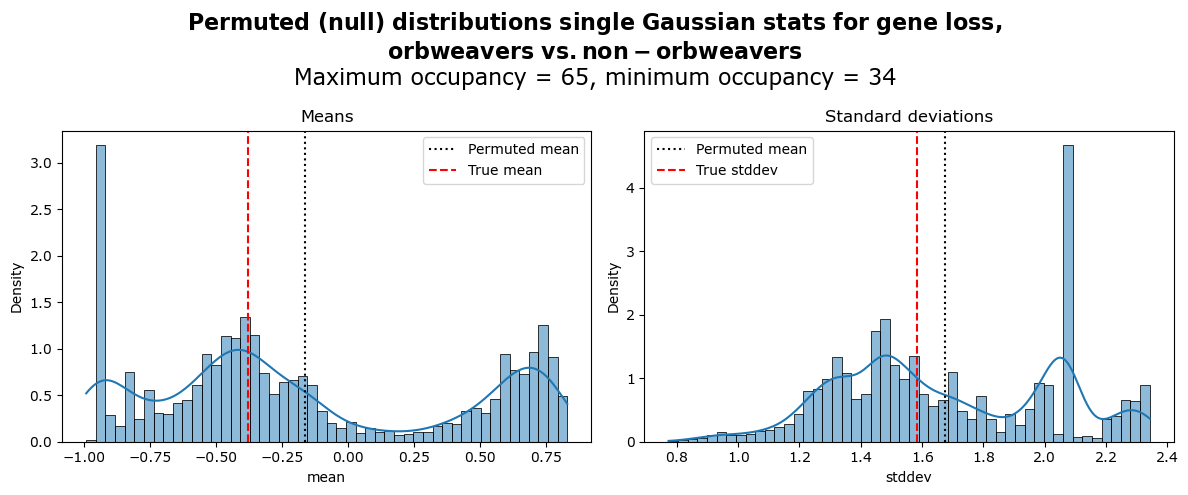

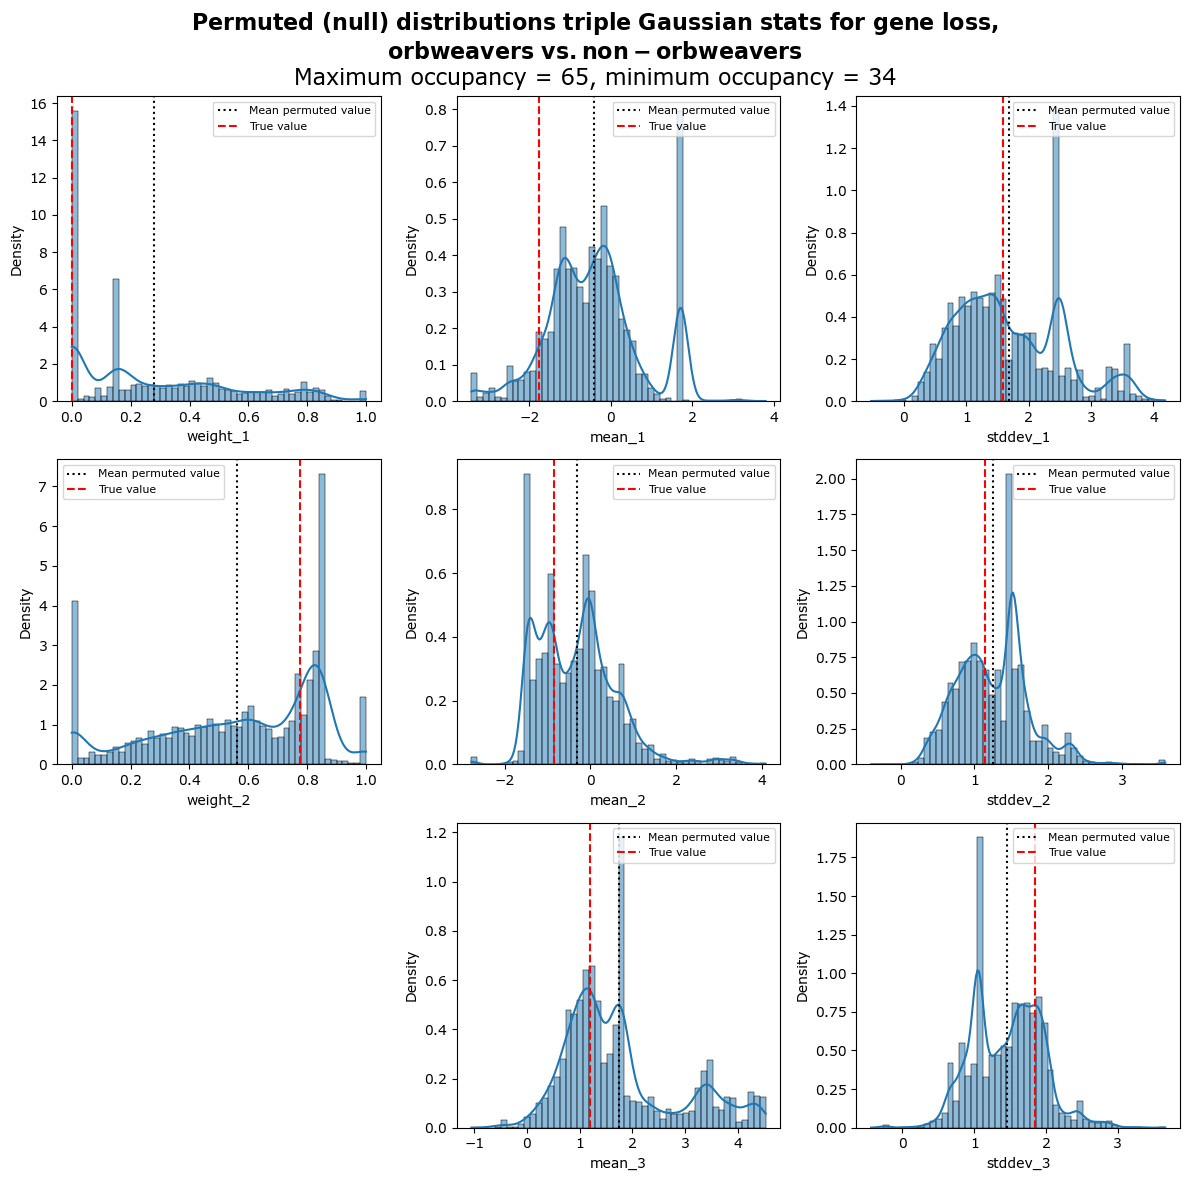

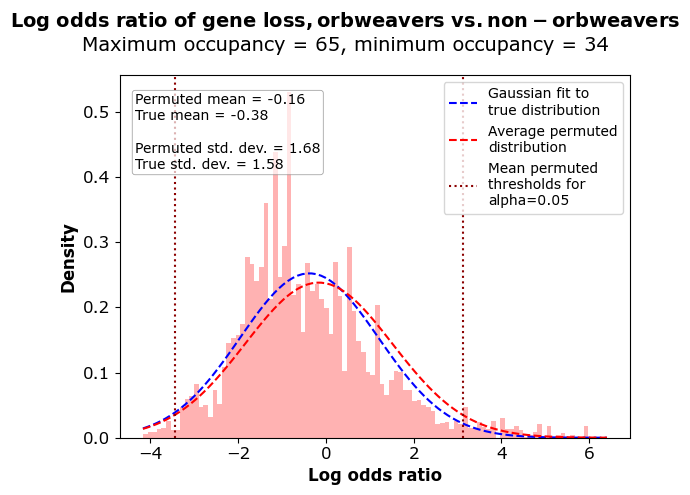

In [6]:
%autoreload 2
loss_lt_34_65 = ort.odds_ratio_test(
    test="loss",
    occupancy_threshold=34,
    max_occ=65,
    alternative="less",
    species_of_interest="Uloborus_diversus",
    results_dir=f"results/odds_ratio_test",
    fg_name='orbweavers',
    bg_name='non-orbweavers',
    foreground_list_filename="data/orbweavers-list-no-araneids.txt",
    background_list_filename="data/non-orb-weavers-no-araneids.txt",
    permulations_tip_values_csv="data/perms_tip_values_no_araneids.csv",
    save_two_tailed_hits=True,
)

## Duplication

68 species total, 17 foreground, 51 background                                                  
Mean: 0.24, Stddev: 1.08, Count: 7911                                                           
Optimized triple Gaussian parameters:                                                           
  weight_1: 0.461                                                                               
  mean_1: 0.255                                                                                 
  stddev_1: 0.840                                                                               
  weight_2: 0.531                                                                               
  mean_2: 0.217                                                                                 
  stddev_2: 1.242                                                                               
  mean_3: 1.467                                                                                 
  stddev_3: 0.991             

  0%|          | 0/10000 [00:00<?, ?it/s]

Permutation counter for MEAN (single Gaussian): 879                                             
Permutation counter for MEAN 1 (triple Gaussian): 305                                           
Permutation counter for MEAN 2 (triple Gaussian): 4776                                          
Permutation counter for MEAN 3 (triple Gaussian): 3373                                          
                                                                                                
Filtering log odds ratio results df for occupancy >= 34, <= 68 with alternative hypothesis      
'two-tailed' and log odds ratio threshold [-2.03848318  2.17641699]                             
                                                                                                
Filtering for presence of Uloborus_diversus                                                     
                                                                                                
*********************** RESULT

Processing HOGs:   0%|          | 0/323 [00:00<?, ?it/s]

Results files saved to                                                                          
/Users/calvin/orb-selection/results/odds_ratio_test/Results_Apr07/Run2_Dup_RT_34-max_10000x     
                                                                                                
Files include:                                                                                  
	 1. [test]_permutation_results.png: True LORs distribution                                     
		vs. average permuted distribution                                                             
	 2. [test]_permutation_stats_dists.png: Histograms of the                                      
		means, standard deviations, and skews of all 10,000                                           
		permuted LOR distributions                                                                    
	 3. [test]_results_summary.txt: Text file summarizing results                                  
	 4. [test].pkl: Pickle file s

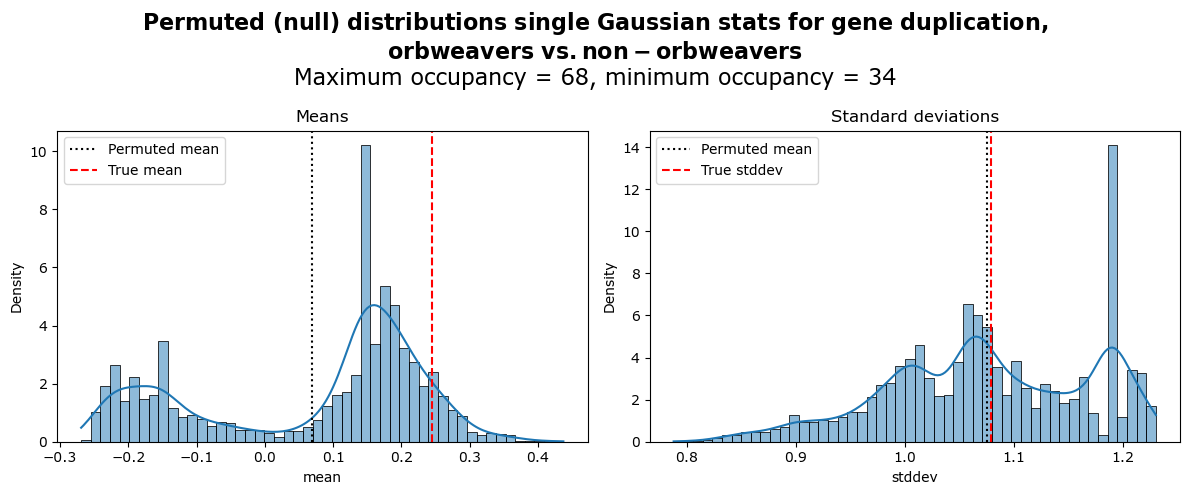

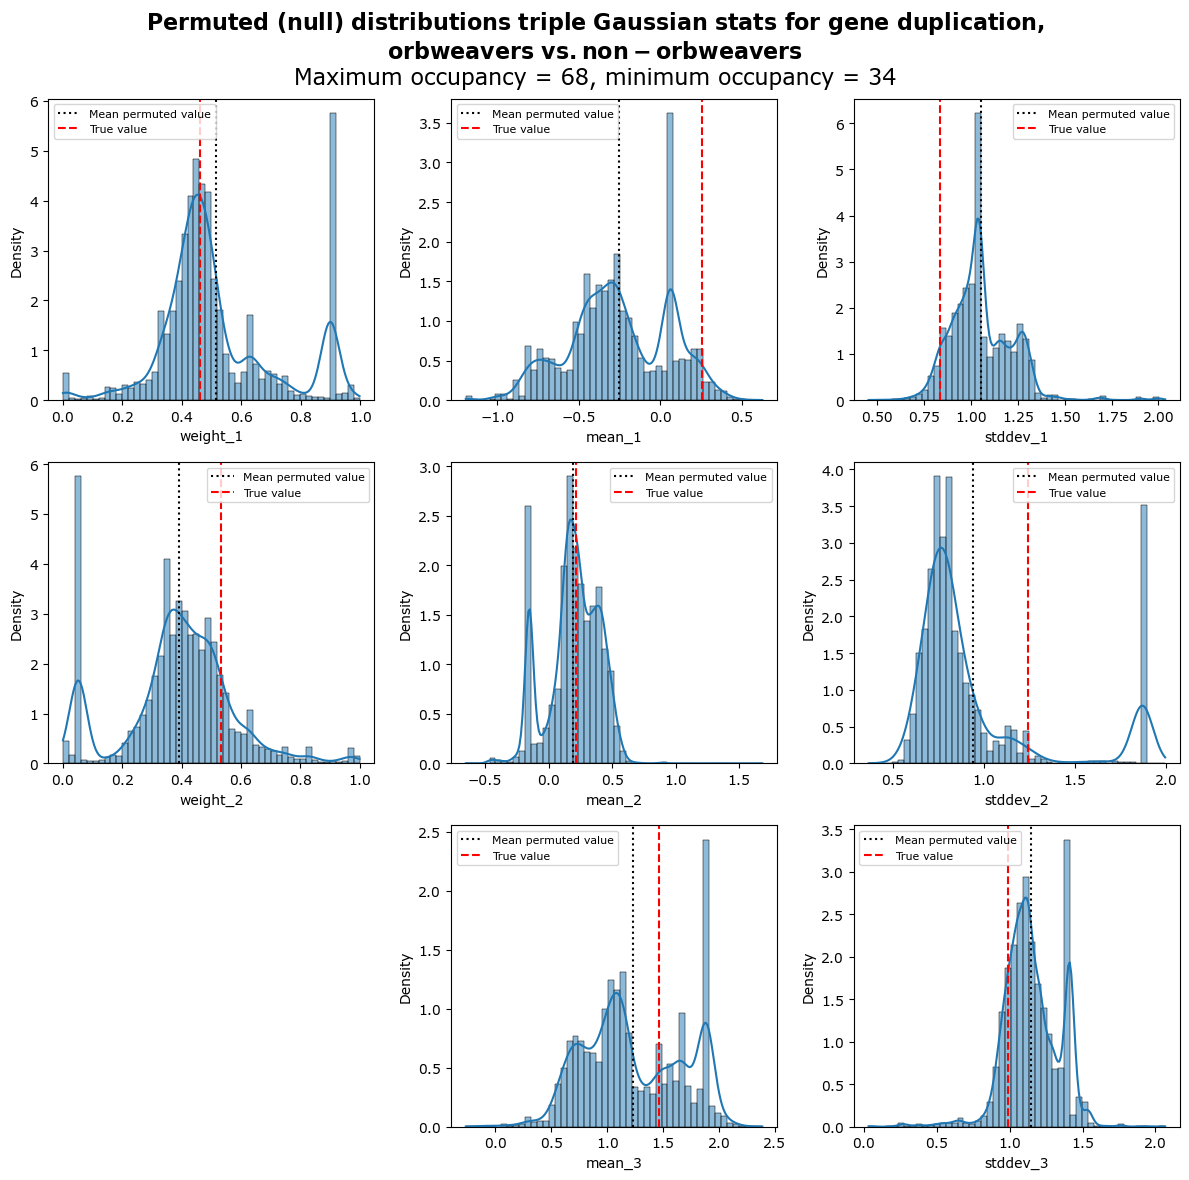

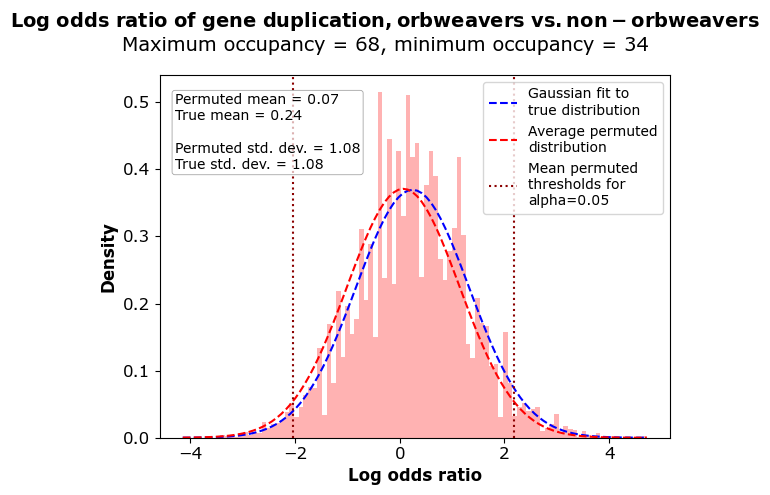

In [7]:
%autoreload 2
dup_rt_34_68 = ort.odds_ratio_test(
    test="duplication",
    occupancy_threshold=34,
    alternative="greater",
    species_of_interest="Uloborus_diversus",
    results_dir=f"results/odds_ratio_test",
    fg_name='orbweavers',
    bg_name='non-orbweavers',
    foreground_list_filename="data/orbweavers-list-no-araneids.txt",
    background_list_filename="data/non-orb-weavers-no-araneids.txt",
    permulations_tip_values_csv="data/perms_tip_values_no_araneids.csv",
    save_two_tailed_hits=True
)

In [3]:
ort_dir = os.path.join(repo_root, "results/odds_ratio_test/Results_Apr07")

# Loss results
ara_loss_results = ort.PermutationTestResults.load_from_pickle(f'{ort_dir}/Run1_Loss_LT_34-65_10000x/loss_occ34-65_less.pkl')
loss_df = ara_loss_results.results_fltrd_df
loss_orb = loss_df[loss_df["Log odds ratio"] > 0]
loss_nonorb = loss_df[loss_df["Log odds ratio"] < 0]

# Duplication results
ara_dup_results = ort.PermutationTestResults.load_from_pickle(f'{ort_dir}/Run2_Dup_RT_34-max_10000x/duplication_occ34-68_greater.pkl')
dup_df = ara_dup_results.results_fltrd_df
dup_orb = dup_df[dup_df["Log odds ratio"] > 0]
dup_nonorb = dup_df[dup_df["Log odds ratio"] < 0]

In [4]:
loss_orb_locs_df = convert_hogs_to_locs(loss_orb, os.path.join(repo_root, "data/N5.tsv"))
loss_orb_locs_list = loss_orb_locs_df['LOC'].drop_duplicates().dropna().tolist()
len(loss_orb_locs_list)

Processing HOGs:   0%|          | 0/133 [00:00<?, ?it/s]

145

In [5]:
loss_nonorb_locs_df = convert_hogs_to_locs(loss_nonorb, os.path.join(repo_root, "data/N5.tsv"))
loss_nonorb_locs_list = loss_nonorb_locs_df['LOC'].drop_duplicates().dropna().tolist()
len(loss_nonorb_locs_list)

Processing HOGs:   0%|          | 0/47 [00:00<?, ?it/s]

53

In [6]:
dup_orb_locs_df = convert_hogs_to_locs(dup_orb, os.path.join(repo_root, "data/N5.tsv"))
dup_orb_locs_list = dup_orb_locs_df['LOC'].drop_duplicates().dropna().tolist()
len(dup_orb_locs_list)

Processing HOGs:   0%|          | 0/214 [00:00<?, ?it/s]

216

In [7]:
dup_nonorb_locs_df = convert_hogs_to_locs(dup_nonorb, os.path.join(repo_root, "data/N5.tsv"))
dup_nonorb_locs_list = dup_nonorb_locs_df['LOC'].drop_duplicates().dropna().tolist()
len(dup_nonorb_locs_list)

Processing HOGs:   0%|          | 0/109 [00:00<?, ?it/s]

108

In [9]:
list_names = ['loss_orb_no_ara', 'loss_nonorb_no_ara'] 
lists = [loss_orb_locs_list, loss_nonorb_locs_list]

for name, lst in zip(list_names, lists):
    filepath = os.path.join(repo_root, f'results/significant_gene_id_lists/loss/{name}.txt')
    with open(filepath, 'w') as f:
        f.write('\n'.join(lst))
    print(f"Wrote {len(lst)} items to {filepath}")

list_names = ['duplication_orb_no_ara', 'duplication_nonorb_no_ara']
lists = [dup_orb_locs_list, dup_nonorb_locs_list]

for name, lst in zip(list_names, lists):
    filepath = os.path.join(repo_root, f'results/significant_gene_id_lists/duplication/{name}.txt')
    with open(filepath, 'w') as f:
        f.write('\n'.join(lst))
    print(f"Wrote {len(lst)} items to {filepath}")

Wrote 145 items to /Users/calvin/orb-selection/results/significant_gene_id_lists/loss/loss_orb_no_ara.txt
Wrote 53 items to /Users/calvin/orb-selection/results/significant_gene_id_lists/loss/loss_nonorb_no_ara.txt
Wrote 216 items to /Users/calvin/orb-selection/results/significant_gene_id_lists/duplication/duplication_orb_no_ara.txt
Wrote 108 items to /Users/calvin/orb-selection/results/significant_gene_id_lists/duplication/duplication_nonorb_no_ara.txt
